In [ ]:
from google.colab import files
newFile = files.upload()

Saving links.csv to links.csv


In [ ]:
from google.colab import files
newFiles = files.upload()

Saving movies.csv to movies.csv


In [ ]:
from google.colab import files
newFilee = files.upload()

Saving ratings.csv to ratings.csv


In [ ]:
from google.colab import files
newFiless = files.upload()

Saving tags.csv to tags.csv


# Retail Optimization with K-Modes Clustering and Association Rule Mining

### Project Goal

This project aims to analyze a dataset of movie ratings and genres to uncover valuable insights for a retail optimization strategy. Using unsupervised machine learning, it will involve:

1.  Clustering Movies: Group similar movies together based on their genres using the K-Modes clustering algorithm.
2.  Discovery of Genre Associations: Identify hidden relationships between genres within each movie cluster using Association Rule Mining.



In [ ]:
# MSc Data Science Project: Data Ingestion, Preprocessing, Summary Statistics, Visualizations, Model training and evaluation
# Dataset: MovieLens (ratings.csv, movies.csv, tags.csv, links.csv)



#  Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [ ]:

# Setting global aesthetics for seaborn
sns.set(style='whitegrid', palette='pastel', font_scale=1.1)

## 2. Data Loading and Preprocessing

In this section, the raw data was loaded into pandas DataFrames andinitial cleaning and preparation was carried out. This includes converting timestamps to a readable format, checking for and handling missing values, and merging the relevant dataframes for unified analysis.

In [ ]:

# Load the CSV datasets

# Upload files via the file upload tool in Colab before running this cell
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
tags = pd.read_csv('tags.csv')
links = pd.read_csv('links.csv')

In [ ]:

# Inspect the Data

print("Ratings Sample:\n", ratings.head())
print("Movies Sample:\n", movies.head())
print("Tags Sample:\n", tags.head())
print("Links Sample:\n", links.head())

Ratings Sample:
    userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
Movies Sample:
    movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
Tags Sample:
    userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotabl

In [ ]:

# Preprocess the Data

# Convert timestamps to datetime format
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

# Check for missing values
print("\nMissing Values Summary:")
print(ratings.isnull().sum())
print(movies.isnull().sum())
print(tags.isnull().sum())
print(links.isnull().sum())

# Remove duplicate tags
tags.drop_duplicates(inplace=True)

# Merge ratings with movies for enriched analysis
ratings_movies = pd.merge(ratings, movies, on='movieId')


Missing Values Summary:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [ ]:

# Summary Statistics

# Basic rating distribution
print("\nRatings Summary:")
print(ratings['rating'].describe())

# Number of unique users and movies
print(f"\nNumber of unique users: {ratings['userId'].nunique()}")
print(f"Number of unique movies: {ratings['movieId'].nunique()}")

# Top 10 most rated movies
top_rated = ratings_movies['title'].value_counts().head(10)
print("\nTop 10 Most Rated Movies:\n", top_rated)



Ratings Summary:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Number of unique users: 610
Number of unique movies: 9724

Top 10 Most Rated Movies:
 title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

EDA is a crucial first step in any data science project. The goal is to visually explore the data to understand its structure, find patterns, and identify potential issues. Here, the distribution of ratings was analyzed and the number of ratings per movie to understand the dataset's characteristics.

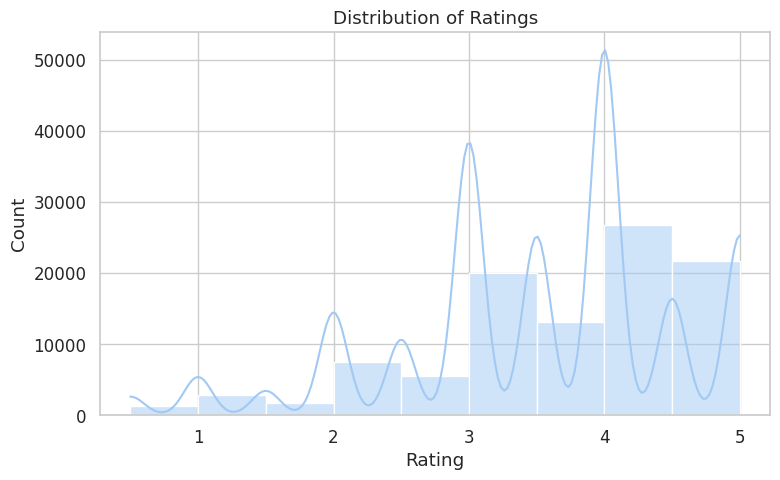

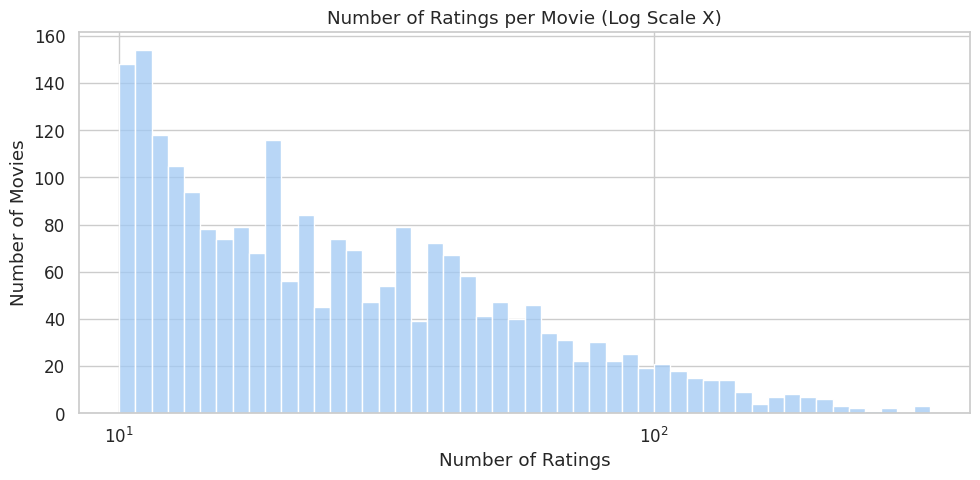

In [ ]:

# Data Visualizations


#  Distribution of Ratings
plt.figure(figsize=(8, 5))
sns.histplot(ratings['rating'], bins=9, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#  Number of Ratings per Movie
ratings_per_movie = ratings['movieId'].value_counts()

# Filter movies with at least 10 ratings
filtered = ratings_per_movie[ratings_per_movie >= 10]

plt.figure(figsize=(10, 5))
sns.histplot(filtered, bins=50, log_scale=True)
plt.title('Number of Ratings per Movie (Log Scale X)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()


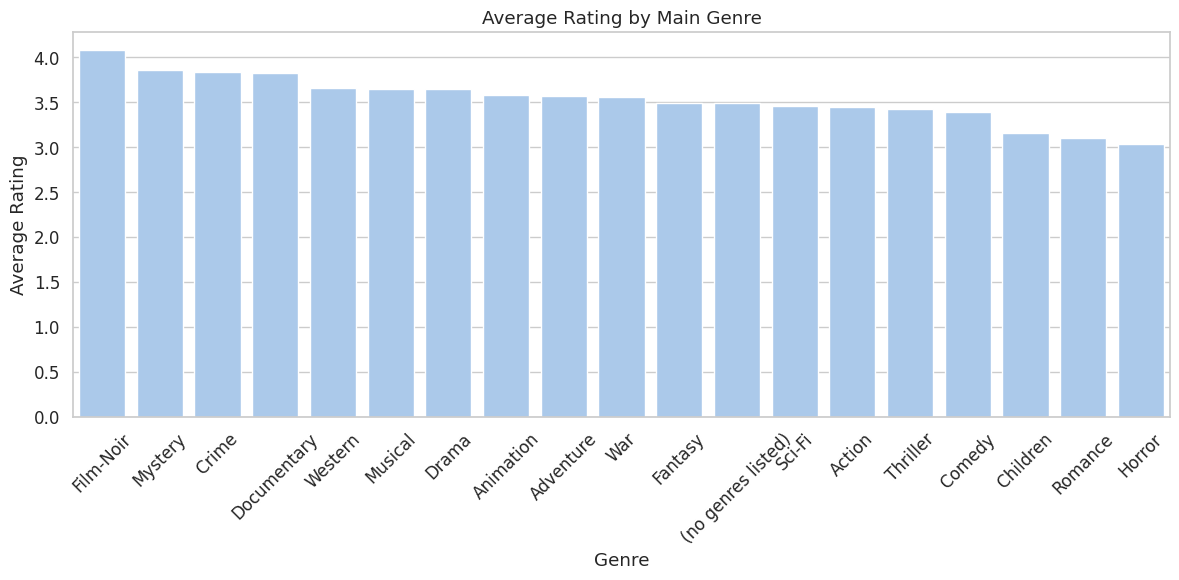

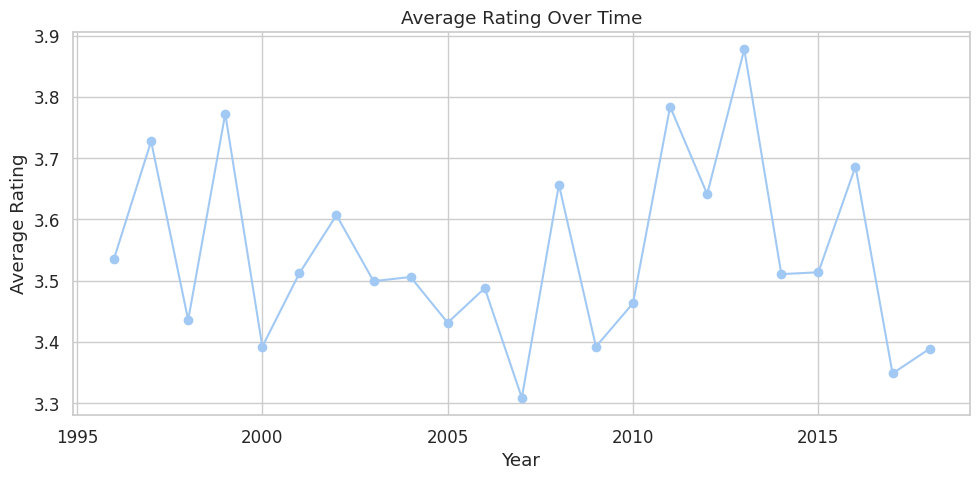

In [ ]:
# Average Rating per Genre (First genre only)
movies['main_genre'] = movies['genres'].apply(lambda x: x.split('|')[0] if isinstance(x, str) else x)
ratings_movies = pd.merge(ratings, movies, on='movieId')
genre_rating = ratings_movies.groupby('main_genre')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_rating.index, y=genre_rating.values)
plt.title('Average Rating by Main Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ratings Over Time
ratings['year'] = ratings['timestamp'].dt.year
ratings_by_year = ratings.groupby('year')['rating'].mean()

plt.figure(figsize=(10, 5))
ratings_by_year.plot(marker='o')
plt.title('Average Rating Over Time')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()


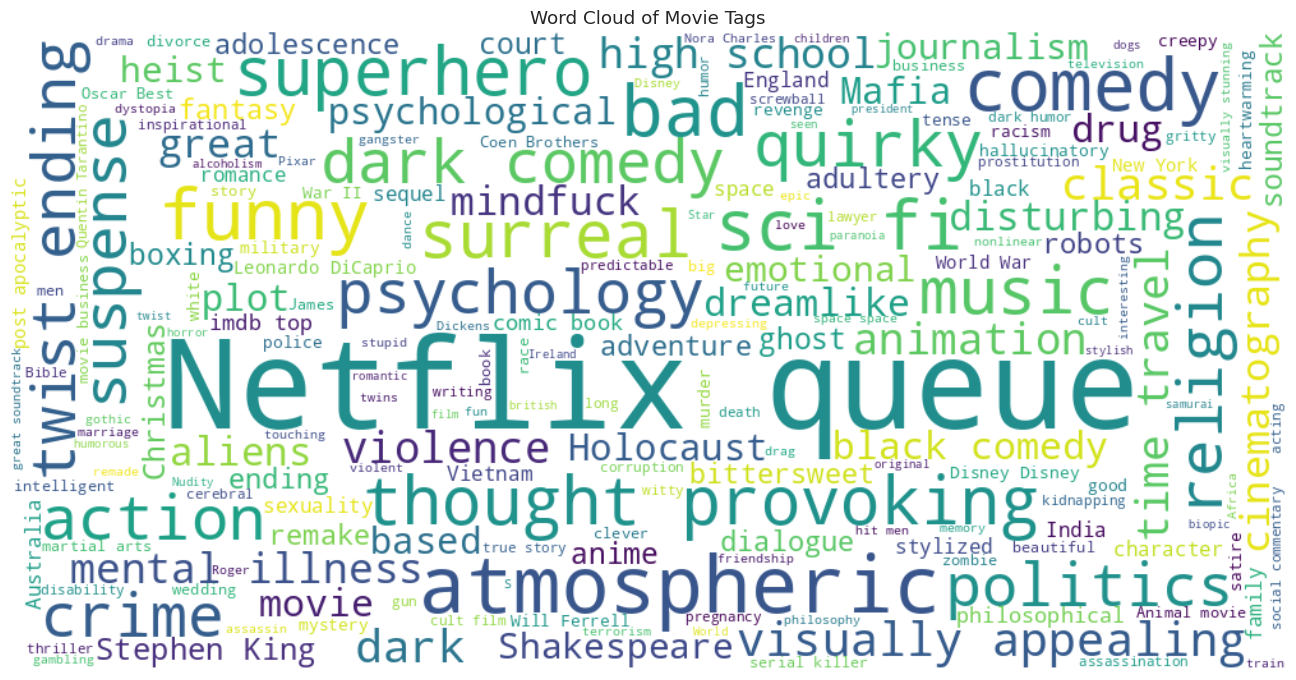

In [ ]:
# Word Cloud from Tags
text = ' '.join(tags['tag'].dropna().astype(str).values)
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Tags')
plt.tight_layout()
plt.show()

In [ ]:
# Install kmodes if not already installed
!pip install kmodes

# Import necessary library for K-Modes clustering
from kmodes.kmodes import KModes



## 4. Methodology: K-Modes Clustering

Since movie genres are categorical data (they are non-numerical labels),traditional clustering algorithms like K-Means cannot be used. Instead, **K-Modes**, an algorithm specifically designed for categorical data was used.

### The Elbow Method

To find the optimal number of clusters (`k`), the Elbow Method was used. The  K-Modes model was trained with a range of `k` values and plot the "cost," which represents the total dissimilarity between each movie and its assigned cluster's center. The ideal `k` is the point on the graph where the cost begins to decrease at a slower rate, creating an "elbow" shape. Based on the plot, the best value for `k` will be selected.

In [ ]:
# Expand genres into individual rows per movie
movies_expanded = movies.copy()
movies_expanded['genres'] = movies_expanded['genres'].str.split('|')
movies_expanded = movies_expanded.explode('genres')

# Create one-hot encoded genre columns using crosstab (more reliable than pivot_table here)
genre_ohe = pd.crosstab(movies_expanded['movieId'], movies_expanded['genres'])

# Reset index to bring 'movieId' back as a column
genre_ohe.reset_index(inplace=True)

# Merge one-hot genre data with movie titles
movies_with_titles = pd.merge(movies[['movieId', 'title']], genre_ohe, on='movieId')

# Prepare the features for K-Modes clustering (exclude ID and title)
X = movies_with_titles.drop(columns=['movieId', 'title'])


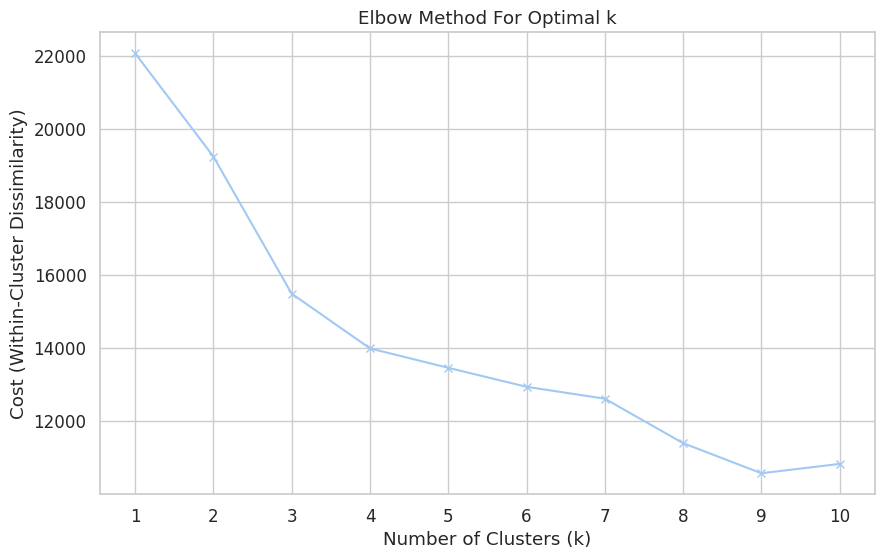

In [ ]:

import matplotlib.pyplot as plt


# We need to find the optimal 'k' for K-Modes using the Elbow Method

# List to hold the cost for each number of clusters
cost = []

# Range of k to test
K = range(1, 11)

for k_value in K:
    kmodes = KModes(n_clusters=k_value, init='Huang', n_init=5, verbose=0)
    kmodes.fit(X) # Replace with the name of your prepared data
    cost.append(kmodes.cost_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K, cost, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost (Within-Cluster Dissimilarity)')
plt.title('Elbow Method For Optimal k')
plt.xticks(K)
plt.show()



In [ ]:
# Apply K-Modes clustering
from kmodes.kmodes import KModes

km = KModes(n_clusters=5, init='Huang', n_init=5, verbose=1)
clusters = km.fit_predict(X)

# Assign clusters back to the main DataFrame
movies_with_titles['Cluster'] = clusters

# View cluster distribution
print("Number of movies per cluster:\n", movies_with_titles['Cluster'].value_counts().sort_index())

# Preview titles per cluster
for i in range(4):
    print(f"\nSample movies from Cluster {i}:\n")
    print(movies_with_titles[movies_with_titles['Cluster'] == i]['title'].head(10))


Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1582, cost: 14343.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 2628, cost: 13920.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 2882, cost: 13797.0
Run 3, iteration: 2/100, moves: 799, cost: 13797.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 16087.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 3060, cost: 13760.0
Run 5, iteration: 2/100, moves: 581, cost: 13760.0
Best run was number 5
Number of movies per cluster:
 Cluster
0    4618
1    1619
2    2017
3     551
4     937
Name: count, dtype: int64

Sample movies from Cluster 0:

0                          Toy Story (1995)
2                   Grumpier

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

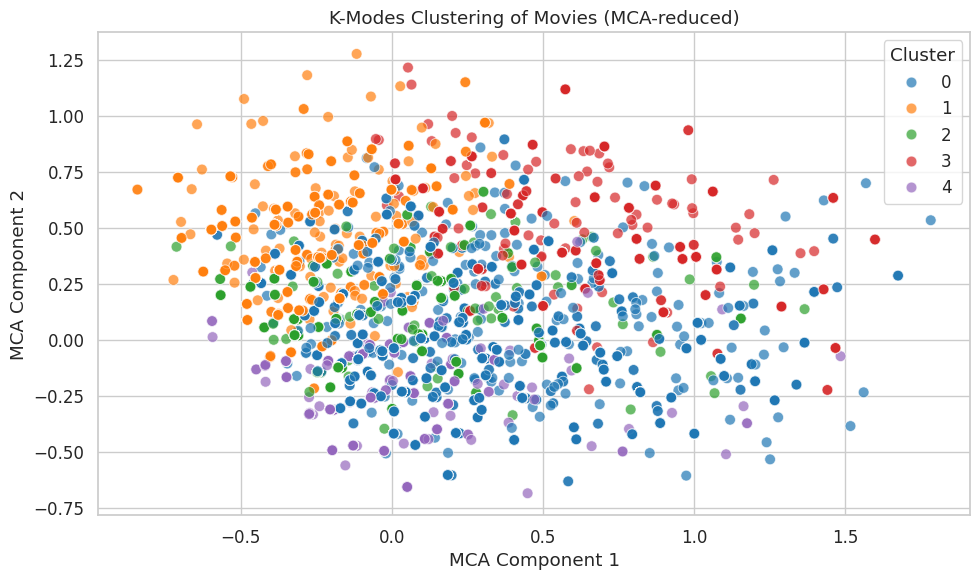

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Install the MCA package (prince)
!pip install prince

# Import MCA from prince
import prince
import matplotlib.pyplot as plt
import seaborn as sns


# Visualize Clusters using MCA


# Re-apply MCA to the feature space (X)
# NOTE: X is one-hot encoded genre data
mca = prince.MCA(n_components=2, random_state=42)
mca_coords = mca.fit_transform(X)

# Add MCA components and cluster labels to a new DataFrame
mca_df = mca_coords.copy()
mca_df['Cluster'] = movies_with_titles['Cluster']

# Plot clusters in 2D MCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(data=mca_df, x=0, y=1, hue='Cluster', palette='tab10', s=60, alpha=0.7)
plt.title('K-Modes Clustering of Movies (MCA-reduced)')
plt.xlabel('MCA Component 1')
plt.ylabel('MCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Methodology: Association Rule Mining

Association Rule Mining is a technique used to discover interesting relationships between items in a large dataset. The key metrics used are:

* **Support:** How often the items appear together.
* **Confidence:** The probability of finding the 'consequent' (the "then" part) given that the 'antecedent' (the "if" part) is present.
* **Lift:** How much more likely the items are to appear together than would be expected by chance. A value greater than 1.0 indicates a positive correlation.

This method will be used to find genre-to-genre relationships that can be used for movie recommendations.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Group genres by movieId (ignore clusters for now)
genre_transactions = movies_expanded.groupby('movieId')['genres'].apply(list).tolist()

# Encode transactions
te = TransactionEncoder()
genre_matrix = te.fit(genre_transactions).transform(genre_transactions)
df_genres = pd.DataFrame(genre_matrix, columns=te.columns_)

# Apply Apriori with low support (0.05 = 5%)
frequent_genres = apriori(df_genres, min_support=0.05, use_colnames=True)
rules_genres = association_rules(frequent_genres, metric='lift', min_threshold=1.0)

# Show top rules
print("Top Association Rules (Genres):\n")
print(rules_genres[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Top Association Rules (Genres):

   antecedents  consequents   support  confidence      lift
0  (Adventure)     (Action)  0.062615    0.482977  2.573940
1     (Action)  (Adventure)  0.062615    0.333698  2.573940
2   (Thriller)     (Action)  0.067235    0.345829  1.843034
3     (Action)   (Thriller)  0.067235    0.358315  1.843034
4    (Romance)     (Comedy)  0.090741    0.553885  1.436620
5     (Comedy)    (Romance)  0.090741    0.235357  1.436620
6      (Drama)      (Crime)  0.065387    0.146067  1.186813
7      (Crime)      (Drama)  0.065387    0.531276  1.186813
8   (Thriller)      (Crime)  0.058407    0.300422  2.440963
9      (Crime)   (Thriller)  0.058407    0.474562  2.440963


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6. Results: Combined Cluster Analysis

Instead of finding general association rules for all movies, association rule mining will be applied to each of the clusters identified by the K-Modes algorithm. This allows discovery of unique genre patterns and preferences within each distinct movie group, leading to more targeted and effective recommendations.

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# --- Step 1: Preprocess the genre data to create `df_genres` ---
# Assuming 'movies_with_titles' and 'movies' DataFrames from previous steps are available
movies_with_genres = movies[['movieId', 'genres']].copy()
movies_with_genres['genres'] = movies_with_genres['genres'].str.split('|')
movies_with_genres = movies_with_genres.explode('genres')

# This line creates the one-hot encoded DataFrame used for association rule mining
df_genres = pd.crosstab(movies_with_genres['movieId'], movies_with_genres['genres'])

# --- Step 2: Combine K-modes clusters with association rule mining ---
# Initialize an empty list to store rules from all clusters
all_rules = []

# Loop through each cluster to find genre associations
for cluster_id in sorted(movies_with_titles['Cluster'].unique()):
    print(f"\n--- Association Rules for Cluster {cluster_id} ---")

    # Filter the movies belonging to the current cluster
    cluster_movies = movies_with_titles[movies_with_titles['Cluster'] == cluster_id]

    # Get the genre data (one-hot encoded) for only these movies
    cluster_genres_data = df_genres.loc[cluster_movies['movieId']]

    # Find frequent genre combinations within this cluster
    frequent_itemsets_cluster = apriori(cluster_genres_data, min_support=0.01, use_colnames=True)

    # Generate the association rules from the frequent combinations
    rules_cluster = association_rules(frequent_itemsets_cluster, metric='lift', min_threshold=1)

    # Add a 'cluster' column to identify the source of the rules
    rules_cluster['cluster'] = cluster_id

    # Append the rules from the current cluster to the list
    all_rules.append(rules_cluster)

    # Sort the rules by confidence and lift to see the strongest ones first
    rules_cluster = rules_cluster.sort_values(by=['confidence', 'lift'], ascending=[False, False])

    # Display the top rules for this cluster
    if not rules_cluster.empty:
        print(rules_cluster.head())
    else:
        print("No association rules found for this cluster.")

# --- Step 3: Combine all rules into a single DataFrame ---
all_rules_df = pd.concat(all_rules, ignore_index=True)
print("\n--- All Rules Combined ---")
print(all_rules_df.head())

# --- Step 4: Perform the quantitative analysis on the combined data ---
# This is the code you will add in a NEW cell after the above steps
print("\n--- Quantitative Analysis of All Discovered Rules ---")

# 1. Total number of unique patterns
total_rules = len(all_rules_df)
print(f"Total number of unique association rules discovered: {total_rules}")

# 2. Count of patterns per cluster
rules_per_cluster = all_rules_df.groupby('cluster').size().sort_index()
print("\nNumber of rules per cluster:")
print(rules_per_cluster)

# 3. Quality of patterns (Lift and Confidence)
print("\nSummary statistics for the quality metrics:")
print(all_rules_df[['lift', 'confidence']].describe())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Association Rules for Cluster 0 ---
            antecedents consequents  antecedent support  consequent support  \
34              (Drama)    (Comedy)            0.136639            0.724773   
38            (Romance)    (Comedy)            0.116934            0.724773   
40           (Thriller)    (Comedy)            0.030749            0.724773   
48  (Adventure, Action)    (Comedy)            0.020572            0.724773   
58   (Thriller, Action)    (Comedy)            0.011910            0.724773   

     support  confidence      lift  representativity  leverage  conviction  \
34  0.136639         1.0  1.379743               1.0  0.037607         inf   
38  0.116934         1.0  1.379743               1.0  0.032183         inf   
40  0.030749         1.0  1.379743               1.0  0.008463         inf   
48  0.020572         1.0  1.379743               1.0  0.005662         inf   
58  0.011910         1.0  1.379743               1.0  0.003278         inf   

    zhangs_metr

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:

# 1. Total number of unique patterns
total_rules = len(all_rules_df)
print(f"Total number of unique association rules discovered: {total_rules}")

# 2. Count of patterns per cluster
rules_per_cluster = all_rules_df.groupby('cluster').size().sort_index()
print("\nNumber of rules per cluster:")
print(rules_per_cluster)

# 3. Quality of patterns (Lift and Confidence)
print("\nSummary statistics for the quality metrics:")
print(all_rules_df[['lift', 'confidence']].describe())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total number of unique association rules discovered: 1422

Number of rules per cluster:
cluster
0    136
1    380
2    102
3    678
4    126
dtype: int64

Summary statistics for the quality metrics:
              lift   confidence
count  1422.000000  1422.000000
mean      2.249966     0.391251
std       2.259242     0.361638
min       1.000000     0.010412
25%       1.063874     0.067941
50%       1.459263     0.250000
75%       2.399540     0.705882
max      23.964194     1.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def recommend_by_genre_rules(input_genres, rules_df, top_n=5):
    input_set = set(input_genres)
    recommendations = []

    for _, row in rules_df.iterrows():
        if row['antecedents'].issubset(input_set):
            recommendations.append((row['consequents'], row['lift']))

    # Sort by lift
    recommendations = sorted(recommendations, key=lambda x: -x[1])

    # Flatten and deduplicate
    result = []
    seen = set()
    for cons, _ in recommendations:
        for genre in cons:
            if genre not in seen:
                result.append(genre)
                seen.add(genre)
            if len(result) >= top_n:
                break
        if len(result) >= top_n:
            break

    return result

# Example: Recommend genres similar to 'Comedy' and 'Romance'
recommend_by_genre_rules(['Comedy', 'Romance'], rules_genres)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

['Comedy', 'Romance', 'Drama']

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Save association rules
rules_genres.to_csv('genre_association_rules.csv', index=False)

# Save cluster assignments
movies_with_titles.to_csv('kmodes_clustered_movies.csv', index=False)

# Save genre transactions
df_genres.to_csv('genre_transactions.csv', index=False)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag